In [ ]:
import os
os.listdir()

['.config', 'sample_data']

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving SampleSuperstore.csv to SampleSuperstore.csv


In [ ]:
import pandas as pd

df = pd.read_csv('SampleSuperstore.csv')
df.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


In [ ]:
df.shape

(9994, 13)

In [ ]:
df.columns

Index(['Ship Mode', 'Segment', 'Country', 'City', 'State', 'Postal Code',
       'Region', 'Category', 'Sub-Category', 'Sales', 'Quantity', 'Discount',
       'Profit'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Ship Mode     9994 non-null   object 
 1   Segment       9994 non-null   object 
 2   Country       9994 non-null   object 
 3   City          9994 non-null   object 
 4   State         9994 non-null   object 
 5   Postal Code   9994 non-null   int64  
 6   Region        9994 non-null   object 
 7   Category      9994 non-null   object 
 8   Sub-Category  9994 non-null   object 
 9   Sales         9994 non-null   float64
 10  Quantity      9994 non-null   int64  
 11  Discount      9994 non-null   float64
 12  Profit        9994 non-null   float64
dtypes: float64(3), int64(2), object(8)
memory usage: 1015.1+ KB


In [ ]:
df.columns = df.columns.str.replace('','_')
df.columns

Index(['_S_h_i_p_ _M_o_d_e_', '_S_e_g_m_e_n_t_', '_C_o_u_n_t_r_y_',
       '_C_i_t_y_', '_S_t_a_t_e_', '_P_o_s_t_a_l_ _C_o_d_e_', '_R_e_g_i_o_n_',
       '_C_a_t_e_g_o_r_y_', '_S_u_b_-_C_a_t_e_g_o_r_y_', '_S_a_l_e_s_',
       '_Q_u_a_n_t_i_t_y_', '_D_i_s_c_o_u_n_t_', '_P_r_o_f_i_t_'],
      dtype='object')

In [ ]:
df.isnull().sum()

,0
_S_h_i_p_ _M_o_d_e_,0
_S_e_g_m_e_n_t_,0
_C_o_u_n_t_r_y_,0
_C_i_t_y_,0
_S_t_a_t_e_,0
_P_o_s_t_a_l_ _C_o_d_e_,0
_R_e_g_i_o_n_,0
_C_a_t_e_g_o_r_y_,0
_S_u_b_-_C_a_t_e_g_o_r_y_,0
_S_a_l_e_s_,0


In [ ]:
df.columns = df.columns.str.strip()   # remove spaces
df.columns = df.columns.str.replace(' ', '_')  # replace spaces only
df.columns = df.columns.str.replace('-', '_')  # fix hyphen
df.columns

Index(['_S_h_i_p___M_o_d_e_', '_S_e_g_m_e_n_t_', '_C_o_u_n_t_r_y_',
       '_C_i_t_y_', '_S_t_a_t_e_', '_P_o_s_t_a_l___C_o_d_e_', '_R_e_g_i_o_n_',
       '_C_a_t_e_g_o_r_y_', '_S_u_b___C_a_t_e_g_o_r_y_', '_S_a_l_e_s_',
       '_Q_u_a_n_t_i_t_y_', '_D_i_s_c_o_u_n_t_', '_P_r_o_f_i_t_'],
      dtype='object')

In [ ]:
df.columns = df.columns.str.replace('_', '')   # remove ALL underscores
df.columns = df.columns.str.strip()            # clean spaces
df.columns = df.columns.str.replace(' ', '_')  # add proper underscores
df.columns

Index(['ShipMode', 'Segment', 'Country', 'City', 'State', 'PostalCode',
       'Region', 'Category', 'SubCategory', 'Sales', 'Quantity', 'Discount',
       'Profit'],
      dtype='object')

In [ ]:
df['Category'].value_counts()

,count
Category,
Office Supplies,6026
Furniture,2121
Technology,1847


In [ ]:
df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

,Sales
Category,
Technology,836154.0330
Furniture,741999.7953
Office Supplies,719047.0320


In [ ]:
df.groupby('Category')['Profit'].sum().sort_values(ascending=False)

,Profit
Category,
Technology,145454.9481
Office Supplies,122490.8008
Furniture,18451.2728


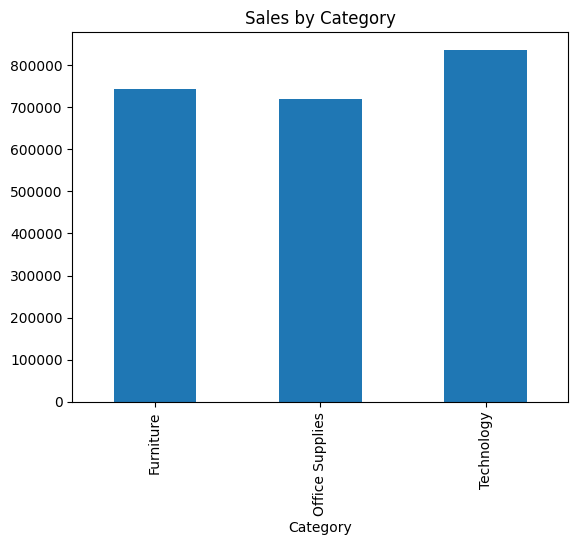

In [ ]:
import matplotlib.pyplot as plt

df.groupby('Category')['Sales'].sum().plot(kind='bar')
plt.title('Sales by Category')
plt.show()

In [ ]:
df.groupby('Region')['Sales'].sum()

,Sales
Region,
Central,501239.8908
East,678781.2400
South,391721.9050
West,725457.8245


In [ ]:
df.groupby('Region')['Profit'].sum().sort_values(ascending=False)

,Profit
Region,
West,108418.4489
East,91522.7800
South,46749.4303
Central,39706.3625


In [ ]:
df.groupby('Region')[['Sales','Profit']].sum()

,Sales,Profit
Region,,
Central,501239.8908,39706.3625
East,678781.2400,91522.7800
South,391721.9050,46749.4303
West,725457.8245,108418.4489


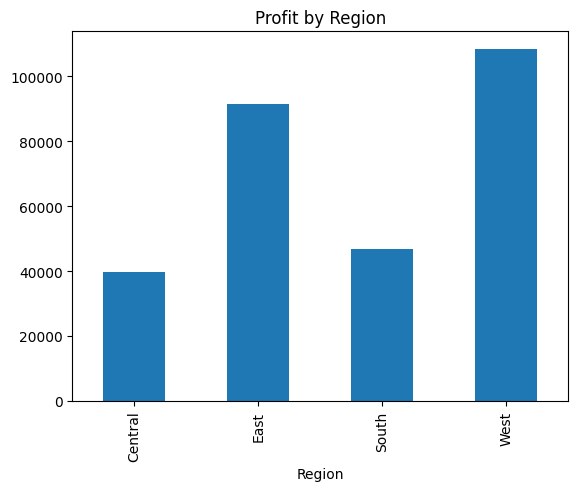

In [ ]:
df.groupby('Region')['Profit'].sum().plot(kind='bar')
plt.title('Profit by Region')
plt.show()

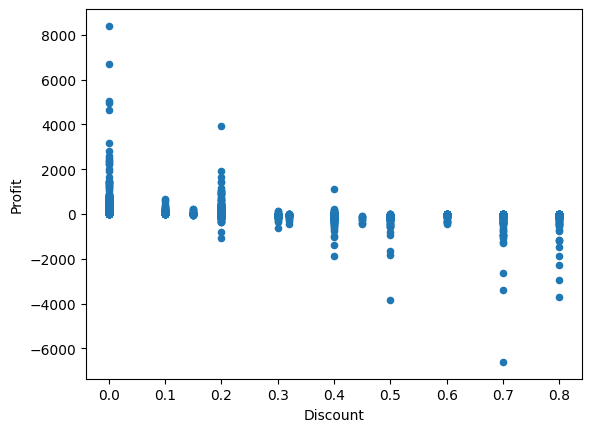

In [ ]:
df.plot(x='Discount', y='Profit', kind='scatter')
plt.show()

In [ ]:
df.groupby('Category')[['Sales','Profit','Discount']].mean()

,Sales,Profit,Discount
Category,,,
Furniture,349.834887,8.699327,0.173923
Office Supplies,119.324101,20.327050,0.157285
Technology,452.709276,78.752002,0.132323


In [ ]:
df.sort_values(by='Profit').head(10)

,ShipMode,Segment,Country,City,State,PostalCode,Region,Category,SubCategory,Sales,Quantity,Discount,Profit
7772,Standard Class,Consumer,United States,Lancaster,Ohio,43130,East,Technology,Machines,4499.985,5,0.7,-6599.9780
683,Same Day,Corporate,United States,Burlington,North Carolina,27217,South,Technology,Machines,7999.980,4,0.5,-3839.9904
9774,Standard Class,Consumer,United States,San Antonio,Texas,78207,Central,Office Supplies,Binders,2177.584,8,0.8,-3701.8928
3011,Standard Class,Home Office,United States,Louisville,Colorado,80027,West,Technology,Machines,2549.985,5,0.7,-3399.9800
4991,Standard Class,Corporate,United States,Chicago,Illinois,60653,Central,Office Supplies,Binders,1889.990,5,0.8,-2929.4845
3151,First Class,Consumer,United States,Newark,Ohio,43055,East,Technology,Machines,1799.994,2,0.7,-2639.9912
5310,First Class,Consumer,United States,Houston,Texas,77095,Central,Office Supplies,Binders,1525.188,6,0.8,-2287.7820
9639,Second Class,Consumer,United States,Concord,North Carolina,28027,South,Furniture,Tables,4297.644,13,0.4,-1862.3124
1199,Standard Class,Consumer,United States,Houston,Texas,77041,Central,Office Supplies,Binders,1088.792,4,0.8,-1850.9464
2697,Standard Class,Home Office,United States,Jacksonville,Florida,32216,South,Technology,Machines,22638.480,6,0.5,-1811.0784


In [ ]:
df[['Discount','Profit']].corr()

,Discount,Profit
Discount,1.000000,-0.219487
Profit,-0.219487,1.000000


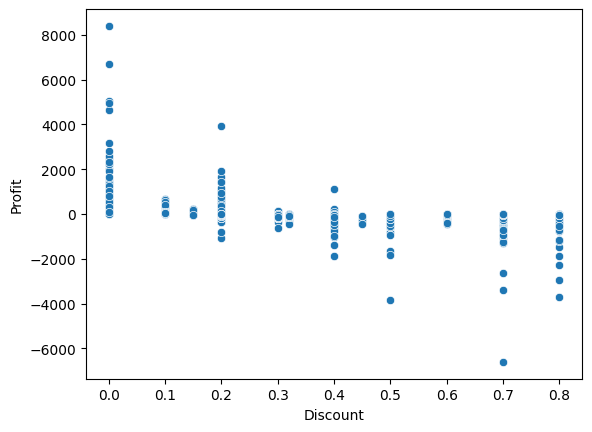

In [ ]:
import seaborn as sns

sns.scatterplot(x='Discount', y='Profit', data=df)
plt.show()

In [ ]:
X = df[['Sales', 'Quantity', 'Discount']]
y = df['Profit']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import mean_absolute_error, r2_score

print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 69.77214730362897
R2 Score: -0.7240890405096132


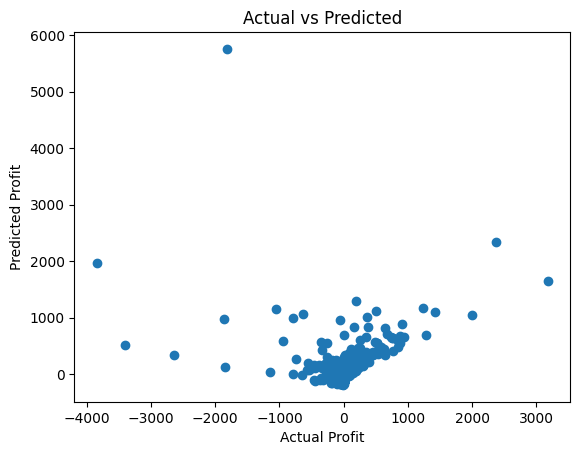

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Profit")
plt.ylabel("Predicted Profit")
plt.title("Actual vs Predicted")
plt.show()

In [ ]:
df_model = df[['Sales','Quantity','Discount','Category','Region','Profit']]

In [ ]:
df_model = pd.get_dummies(df_model, drop_first=True)

In [ ]:
X = df_model.drop('Profit', axis=1)
y = df_model['Profit']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor()
model.fit(X_train, y_train)

RandomForestRegressor()

In [ ]:
y_pred = model.predict(X_test)

from sklearn.metrics import r2_score

print("R2 Score:", r2_score(y_test, y_pred))

R2 Score: -0.2577766384856617


In [ ]:
df_model = df[['Sales','Quantity','Discount','Category','SubCategory','Region','Profit']]

In [ ]:
df_model = pd.get_dummies(df_model, drop_first=True)

In [ ]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestRegressor(max_depth=10, n_estimators=200, random_state=42)

In [ ]:
y_pred = model.predict(X_test)

from sklearn.metrics import r2_score
print("R2 Score:", r2_score(y_test, y_pred))

R2 Score: -0.18506197507811306
